# Import

In [1]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

import sys
sys.path.append('../src')
import ice

# PCA

In [ ]:
# attenu_pca = sklearn.decomposition.PCA(n_components = 32)

# attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
# attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard)
# attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

# train_size = int(0.7 * len(attenu_fromEm_standard))
# val_size = int((len(attenu_fromEm_standard) - train_size)/2)
# test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

# generator = torch.Generator().manual_seed(42)
# attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

# torch.save(attenu_fromEm_train_dataset, 'attenu_fromEm_train_dataset.pt')
# torch.save(attenu_fromEm_val_dataset, 'attenu_fromEm_val_dataset.pt')
# torch.save(attenu_fromEm_test_dataset, 'attenu_fromEm_test_dataset.pt')

# attenu_pca.fit(attenu_fromEm_train_dataset[:][0].detach().numpy()[:, 0, :, :].reshape((-1, attenu_fromEm_train_dataset[:][0].shape[2] ** 2)))

# import joblib

# joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 

In [ ]:
# # detect if there are repeated samples
# unique_count = []
# for i in range(attenu_latent.shape[1]):
#     unique_count.append(torch.unique(attenu_latent[:, i]).shape[0])

In [113]:
# load data: attenuation rate in PCA latent space
#num_epochs = 50
batch_size = 64

#attenu_pca = sklearn.decomposition.PCA(n_components = 32)
attenu_pca = joblib.load('../testing/attenu_pca2026-06-24 15:25:36.840671.pkl')
attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
attenu_latent = attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
attenu_latent = torch.tensor(attenu_latent).float()

import joblib
#joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 
torch.save(attenu_latent, 'attenu_latent_pca.pt')

# # convert PCA coefficients to z-score
# attenu_latent_std = torch.std(attenu_latent, axis = 0)
# attenu_latent_mean = torch.mean(attenu_latent, axis = 0)
# attenu_latent_std = torch.tile(attenu_latent_std, (attenu_latent.shape[0], 1))
# attenu_latent_mean = torch.tile(attenu_latent_mean, (attenu_latent.shape[0], 1))

# attenu_latent_standard = (attenu_latent - attenu_latent_mean) / attenu_latent_std


# train val test split
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)
#attenu_latent_dataset = TensorDataset(attenu_latent_standard, attenu_latent_standard)

train_size = (int(0.7 * len(attenu_latent_dataset)) // batch_size) * batch_size
val_size = int((len(attenu_latent_dataset) - train_size)/2)
test_size = int(len(attenu_latent_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

Text(0.5, 1.0, 'cumulative explained variance')

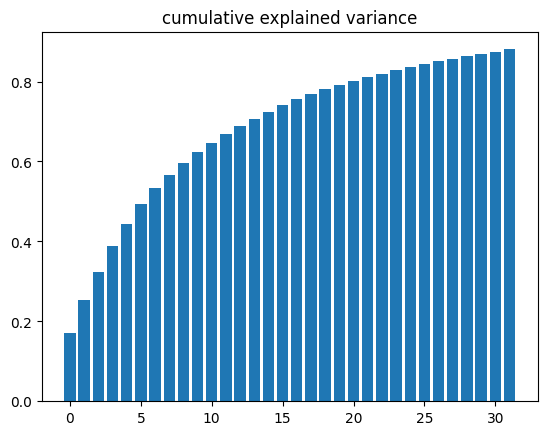

In [114]:
plt.bar(np.arange(np.cumsum(attenu_pca.explained_variance_ratio_).shape[0]), height = np.cumsum(attenu_pca.explained_variance_ratio_))
plt.title("cumulative explained variance")

# Architecture (normflows, real NVP)

In [115]:
# # Set up model_nf
# in_features = int(attenu_latent.shape[1]/2)

# # Define list of flows
# num_layers = 256
# flows = []
# for i in range(num_layers):
#     # Neural network with two hidden layers having 64 units each
#     # Last layer is initialized by zeros making training more stable
#     param_map = nf.nets.MLP([in_features, 64, 64, in_features * 2], init_zeros=True)
#     # Add flow layer
#     flows.append(nf.flows.AffineCouplingBlock(param_map))
#     # Swap dimensions
#     flows.append(nf.flows.Permute(in_features * 2, mode='swap'))

# # base distribution is a Gaussian with num of dimension same as training data
# base = nf.distributions.base.DiagGaussian(in_features * 2)

# # Construct flow model_nf
# model_nf = nf.NormalizingFlow(base, flows)

# model_nf

# # # Set up model_nf
# # in_features = int(attenu_latent.shape[1]/2)

# # # Define list of flows
# # num_layers = 8
# # flows = []
# # for i in range(num_layers):
# #     # Neural network with two hidden layers having 64 units each
# #     # Last layer is initialized by zeros making training more stable
# #     param_map = nf.nets.MLP([16, 64, 64, 32], init_zeros=True)
# #     # Add flow layer
# #     flows.append(nf.flows.AffineCouplingBlock(param_map))
# #     # Swap dimensions
# #     flows.append(nf.flows.Permute(32, mode='swap'))

# # # base distribution is a Gaussian with num of dimension same as training data
# # base = nf.distributions.base.DiagGaussian(32)

# # # Construct flow model_nf
# # model_nf = nf.NormalizingFlow(base, flows)

# # model_nf

# Architecture (glow)

In [157]:
# Define flows
L = 3
K = 16
torch.manual_seed(0)

channels = 1
hidden_channels = 64
split_mode = 'channel'
scale = True

# Set up flows, distributions and merge operations
q0 = []
merges = []
flows = []
for i in range(L):
    flows_ = []
    for j in range(K):
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale, leaky = 0.1)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]
    if i > 0:
        merges += [nf.flows.Merge()]
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L, 
                        input_shape[2] // 2 ** L)
q0 += [nf.distributions.base.DiagGaussian(32)]


# Construct flow model with the multiscale architecture
model = nf.MultiscaleFlow(q0, flows, merges)

In [158]:
model

MultiscaleFlow(
  (q0): ModuleList(
    (0): DiagGaussian()
  )
  (flows): ModuleList(
    (0): ModuleList(
      (0-15): 16 x GlowBlock(
        (flows): ModuleList(
          (0): AffineCouplingBlock(
            (flows): ModuleList(
              (0): Split()
              (1): AffineCoupling(
                (param_map): ConvNet2d(
                  (net): Sequential(
                    (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                    (1): LeakyReLU(negative_slope=0.1)
                    (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
                    (3): LeakyReLU(negative_slope=0.1)
                    (4): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                  )
                )
              )
              (2): Merge()
            )
          )
          (1): Invertible1x1Conv()
          (2): ActNorm()
        )
      )
      (16): Squeeze()
    )
    (1): ModuleList(
      (0-15): 16 x GlowBl

# Training

In [150]:
# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf
max_epoch = 50000
early_stopping_threshold = 1e-6

epoch_loss = np.array([])
epoch_loss_val = np.array([])

optimizer = torch.optim.Adam(model_nf.parameters(), lr=1e-5, weight_decay=1e-5)
model_nf.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_train_dataloader:
            # Compute loss
            loss = model_nf.forward_kld(train_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_val_dataloader:
            # Compute loss
            val_loss = model_nf.forward_kld(val_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                optimizer.step()
                running_loss_val += val_loss.item() * val_batch.size(0)
        
        #print(running_loss)

        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_
            print(f"Epoch loss slope: {epoch_loss_slope}")

            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")

            if (np.abs(epoch_loss_slope) < early_stopping_threshold) or (np.abs(epoch_loss_val_slope) < early_stopping_threshold):
                print("Early stopping")
                break

        end.record()

        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

    torch.save(model_nf.state_dict(), f'glow_{datetime.datetime.now()}.pth')
    np.savez(f'glow_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf.state_dict(), f'glow_{datetime.datetime.now()}.pth')
    np.savez(f'glow_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/50000], loss: 16.4869, validation loss: 52.7580, time elapsed = 0.23 s
Epoch [2/50000], loss: 22.2401, validation loss: 71.1684, time elapsed = 0.20 s
Epoch [3/50000], loss: 18.4685, validation loss: 59.0991, time elapsed = 0.21 s
Epoch [4/50000], loss: 19.9119, validation loss: 63.7182, time elapsed = 0.23 s
Epoch [5/50000], loss: 19.2544, validation loss: 61.6140, time elapsed = 0.23 s
Epoch [6/50000], loss: 18.3152, validation loss: 58.6088, time elapsed = 0.24 s
Epoch [7/50000], loss: 18.6881, validation loss: 59.8019, time elapsed = 0.24 s
Epoch [8/50000], loss: 17.9917, validation loss: 57.5733, time elapsed = 0.20 s
Epoch [9/50000], loss: 17.0753, validation loss: 54.6408, time elapsed = 0.21 s
Epoch [10/50000], loss: 17.1825, validation loss: 54.9840, time elapsed = 0.22 s
Epoch [11/50000], loss: 16.4964, validation loss: 52.7885, time elapsed = 0.23 s
Epoch [12/50000], loss: 16.4360, validation loss: 52.5952, time elapsed = 0.24 s
Epoch [13/50000], loss: 16.0960, vali

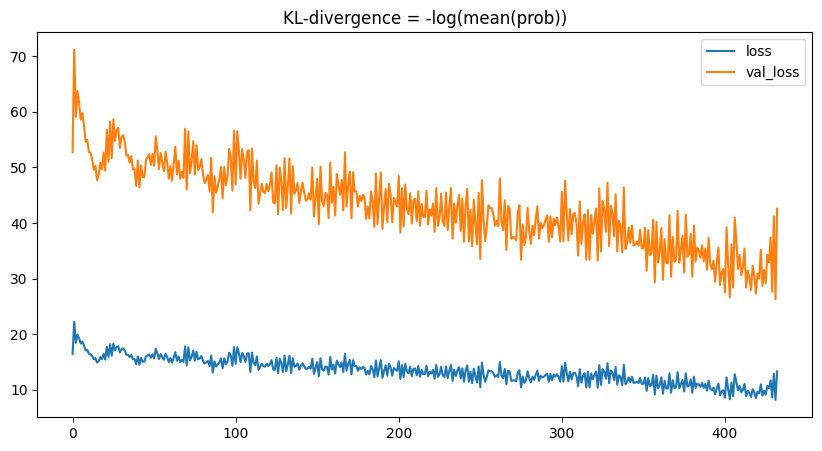

In [151]:
# Plot loss
#epoch_loss = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss']
#epoch_loss_val = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss_val']

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss[0:-1], label='loss')
plt.plot(epoch_loss_val[0:-1], label='val_loss')
plt.title('KL-divergence = -log(mean(prob))')
plt.legend()
plt.show()


# Sampling

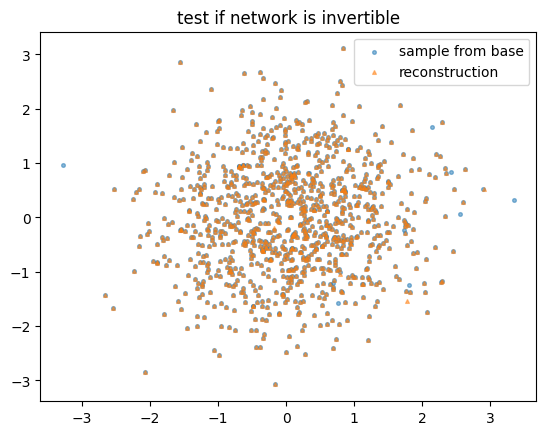

In [152]:
#model_nf.load_state_dict(torch.load('../testing/realNVP_2026-07-01 15:44:34.646170.pth', weights_only=True))
model_nf.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf.forward(x0)
x1 = model_nf.sample(1000)[0]
x0_from_x1_from_x0 = model_nf.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

plt.scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
plt.scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
plt.title("test if network is invertible")
plt.legend()

(-0.1, 0.1)

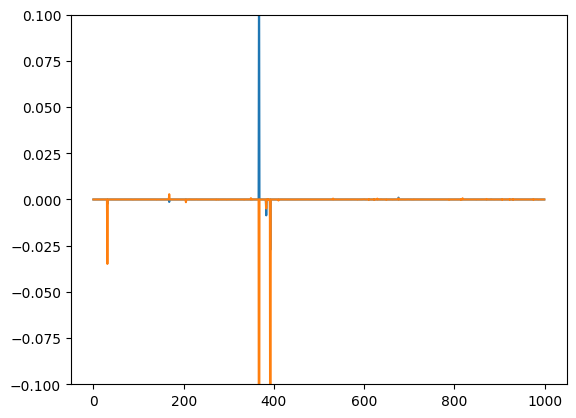

In [153]:
plt.plot(x0_from_x1_from_x0[:, 0] - x0[:, 0])
plt.plot(x0_from_x1_from_x0[:, 1] - x0[:, 1])
plt.ylim((-0.1, 0.1))

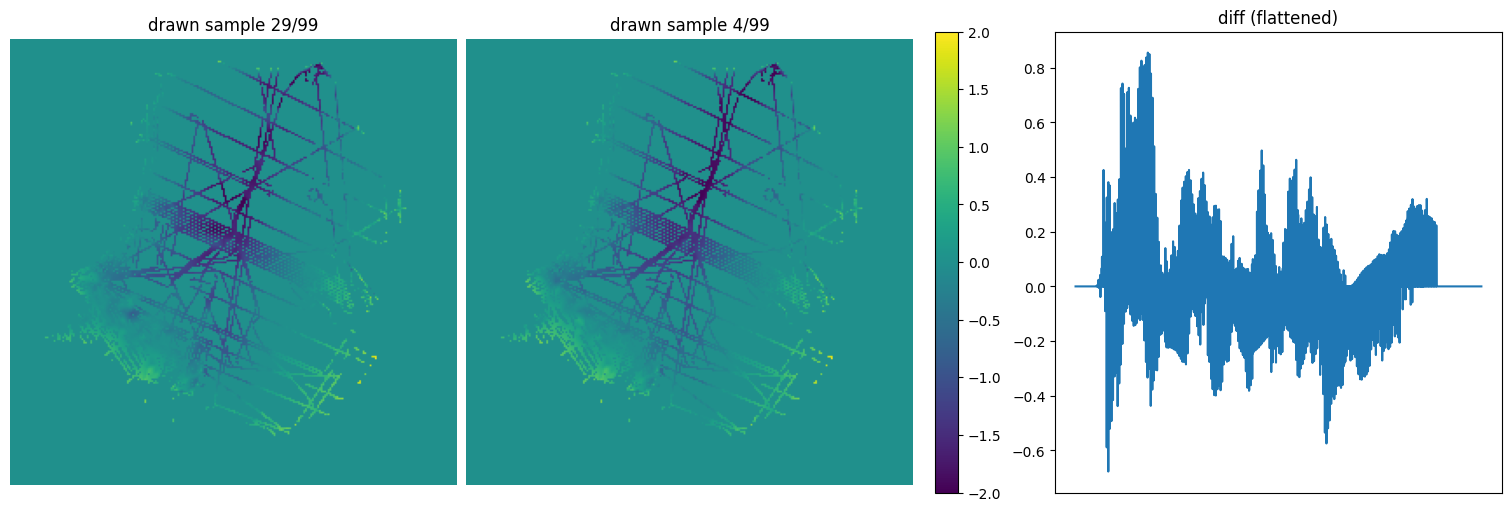

In [154]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_latent, attenu_samples_log_prob = model_nf.sample(100)
attenu_samples_latent = attenu_samples_latent
attenu_samples_latent = attenu_samples_latent[(~torch.isnan(attenu_samples_log_prob)) & (~torch.isinf(attenu_samples_log_prob)), :]
attenu_samples_latent[attenu_samples_latent == torch.nan] = 0
attenu_samples_latent[attenu_samples_latent == torch.inf] = 0
attenu_samples_latent[attenu_samples_latent == -torch.inf] = 0
attenu_samples = attenu_pca.inverse_transform(attenu_samples_latent.detach().numpy())
attenu_samples = attenu_samples.reshape((attenu_samples_latent.shape[0], 256, 256))

figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_samples[idx[0], :, :] - attenu_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

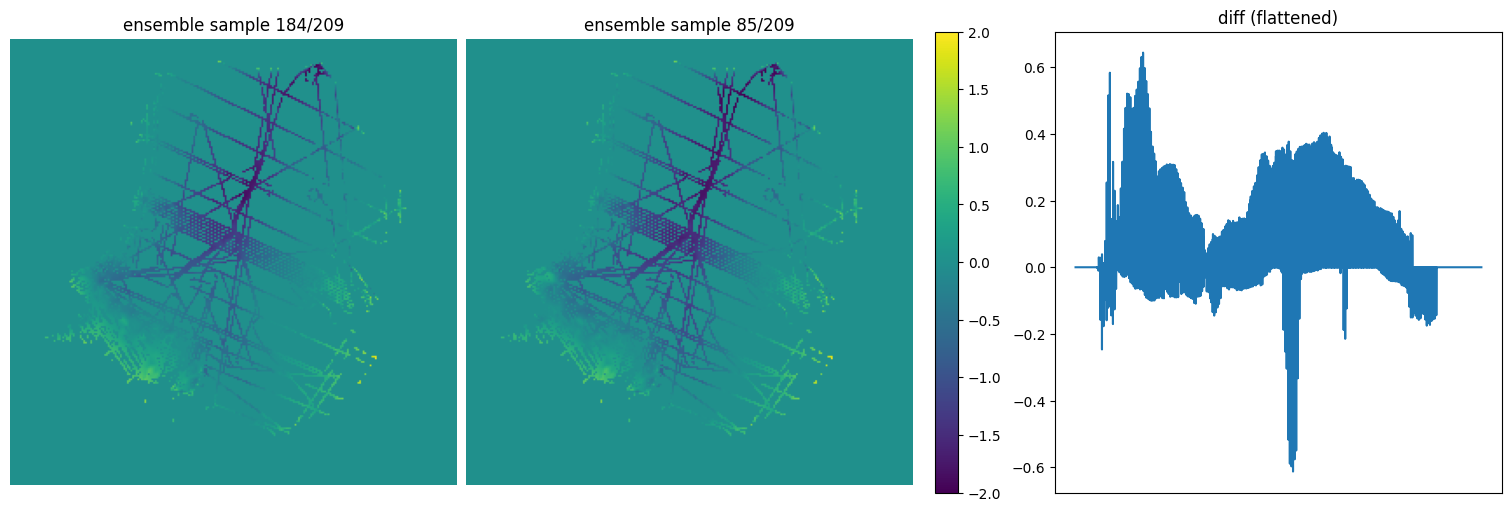

In [155]:
# compare variance to ensemble samples

attenu_ensemble_samples = attenu_pca.inverse_transform(attenu_latent.detach().numpy())
attenu_ensemble_samples = attenu_ensemble_samples.reshape((attenu_ensemble_samples.shape[0], 256, 256))
figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_ensemble_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_ensemble_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"ensemble sample {idx[0]}/{attenu_ensemble_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_ensemble_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"ensemble sample {idx[1]}/{attenu_ensemble_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_ensemble_samples[idx[0], :, :] - attenu_ensemble_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

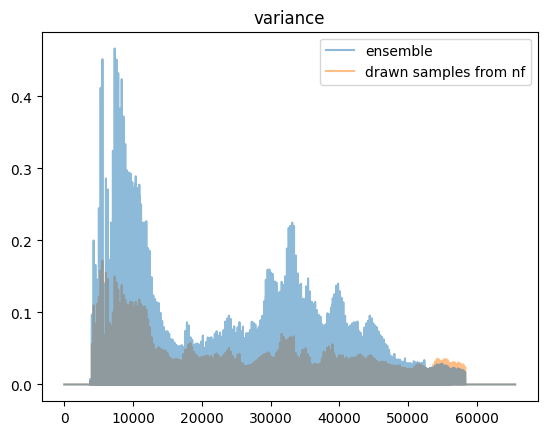

In [156]:
var_attenu_ensemble_samples = np.var(attenu_ensemble_samples, axis = 0)
var_attenu_samples = np.var(attenu_samples, axis = 0)
plt.plot(var_attenu_ensemble_samples.flatten(), label = 'ensemble', alpha = 0.5, zorder = 5)
plt.plot(var_attenu_samples.flatten(), label = 'drawn samples from nf', alpha = 0.5)
plt.title("variance")
plt.legend()

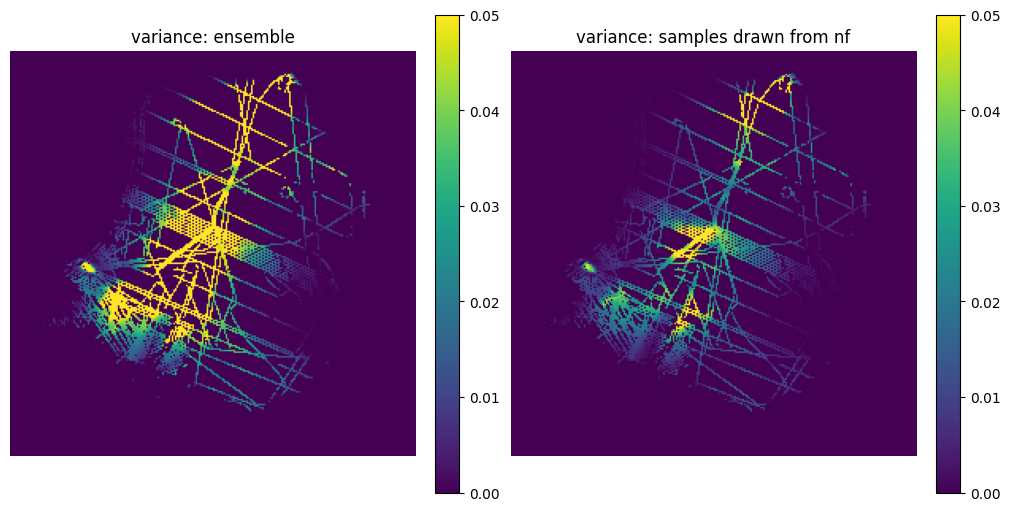

In [112]:
figs, axs = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

vmin = 0
vmax = 0.05

im0 = axs[0].imshow(var_attenu_ensemble_samples, vmin = vmin, vmax = vmax)
axs[0].set_title(f"variance: ensemble")
axs[0].set_axis_off()
plt.colorbar(im0)

im1 = axs[1].imshow(var_attenu_samples, vmin = vmin, vmax = vmax)
axs[1].set_title(f"variance: samples drawn from nf")
axs[1].set_axis_off()
plt.colorbar(im1)

## Verify Autograd

In [22]:
z = base.sample(1)
log_prob_z = base.log_prob(z)
x, log_det_z_to_x = model_nf.forward_and_log_det(z)
z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
x = model_nf.forward(z)
log_prob_x = model_nf.log_prob(x)

# note: log det have opposite sign as defined in this package
# p(x) = p(z) + log(det(Jacobian(f(z->x)))) = p(z) - (log det output by model_nf.forward_and_log_det(z))
log_det_z_to_x = -log_det_z_to_x
log_det_x_to_z = -log_det_x_to_z

In [23]:
z = base.sample(10)
log_prob_z = base.log_prob(z)
#x, log_det_z_to_x = model_nf.forward_and_log_det(z)
#z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
x = model_nf.forward(z)
log_prob_x = model_nf.log_prob(x)

grad_autograd = torch.full(x.shape, float('nan'))

for i in range(len(log_prob_x)):
    grad_autograd[i, :] = torch.autograd.grad(log_prob_x[i], x, retain_graph= True)[0][i, :]

In [24]:
# central diff
grad_fd = torch.zeros(x.shape)

#step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
#diff_central = []
#diff_logp1_central = []

step = 5e-6

for i in range(grad_fd.shape[0]):
    for j in range(grad_fd.shape[1]):

        x_perturb_positive = x.clone().detach()
        x_perturb_positive = x_perturb_positive[i:i+1, :]
        x_perturb_positive[0,j] += step

        x_perturb_negative = x.clone().detach()
        x_perturb_negative = x_perturb_negative[i:i+1, :]
        x_perturb_negative[0,j] -= step

        log_prob_x_perturb_positive = model_nf.log_prob(x_perturb_positive)
        log_prob_x_perturb_negative = model_nf.log_prob(x_perturb_negative)

        diff_central = ((log_prob_x_perturb_positive - log_prob_x_perturb_negative)/(step * 2))
        #diff_central = ((log_p1_sample_perturb_positive - log_p1[i])/(step))
        grad_fd[i,j] = diff_central

grad_fd = grad_fd.detach().numpy()

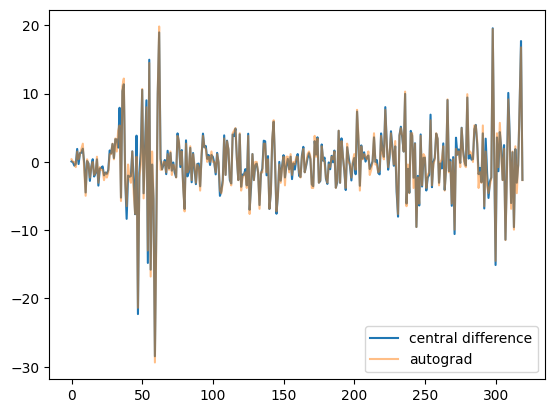

In [25]:
plt.plot(grad_autograd.flatten(), label = 'central difference')
plt.plot(grad_fd.flatten(), alpha = 0.5, label = 'autograd')
plt.legend()

# HMC

In [26]:
# from hamiltonianMC_nf import custom_energy
# x_single_sample = base.sample(1)
# a = custom_energy.apply(x_single_sample, model_nf)
# a.backward()
# x_single_sample.grad

In [27]:
x, log_prob = model_nf.sample(1)
z = model_nf.inverse(x)
z1 = z @ torch.tensor(attenu_pca.components_).float() + torch.tensor(attenu_pca.mean_)
#z1 = torch.matmul(torch.tensor(attenu_pca.components_).float().T, z.T) + torch.tensor(attenu_pca.mean_[:, np.newaxis])
#z2 = attenu_pca.inverse_transform(z.detach().numpy())
gaussian_z1 = torch.distributions.Normal(z1, torch.full(z1.shape, 0.1))

In [240]:
x0 = model_nf.sample(1)[0]
z0 = model_nf.inverse(x0)

z0_image = torch.matmul(z0, torch.tensor(attenu_pca.components_).float())

In [363]:
z0_image

tensor([[ 8.4522e-15, -2.9394e-17,  4.3289e-14,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]], dtype=torch.float64,
       grad_fn=<AddBackward0>)

In [ ]:
# # x, log_prob = model_nf.sample(1)
# # z = model_nf.inverse(x)
# # z1 = z @ torch.tensor(attenu_pca.components_).float() + torch.tensor(attenu_pca.mean_)
# # #z1 = torch.matmul(torch.tensor(attenu_pca.components_).float().T, z.T) + torch.tensor(attenu_pca.mean_[:, np.newaxis])
# # #z2 = attenu_pca.inverse_transform(z.detach().numpy())
# # gaussian_z1 = torch.distributions.Normal(z1, torch.full(z1.shape, 0.1))

# class custom_potential:
#     def __init__(self, model_nf, model_pca):
#         self.model_nf = model_nf
#         self.model_pca = model_pca
    
#     def log_posterior(self, params):
#         x = params['x']
#         x0 = params['x0']

#         # print("x")
#         # print(x)
#         # print("x0")
#         # print(x)


#         # transform to nf latent space
#         z0 = model_nf.inverse(x0)

#         # transform to image space
#         z0_image = torch.matmul(z0, torch.tensor(self.model_pca.components_).float()) + torch.tensor(self.model_pca.mean_)
#         # form Gaussian in latent space
#         gaussian_z0_image = torch.distributions.Normal(z0_image, torch.full(z0_image.shape, 1))
        
#         z = model_nf.inverse(x)
#         z_image = torch.matmul(z, torch.tensor(self.model_pca.components_).float()) + torch.tensor(self.model_pca.mean_)

#         print(gaussian_z0_image.log_prob(z_image)[0][0])
    
#         return -(model_nf.log_prob(x) + gaussian_z0_image.log_prob(z_image)[0][0])

# #custom_potential = custom_potential(model_nf, attenu_pca)

# # grad = torch.autograd.grad(custom_potential.forward(x), x, retain_graph= True)

# import pyro
# from pyro.infer.mcmc import MCMC, HMC, NUTS

# # def potential_fn(params):
# #     x = params['x']
# #     return -model_nf.log_prob(x)

# custom_potential = custom_potential(model_nf, attenu_pca)

# hmc_kernel = HMC(potential_fn = custom_potential.log_posterior, step_size=0.01, num_steps=1)
# #nuts_kernel = NUTS(potential_fn = custom_potential.log_posterior)

# num_steps = 10
# samples = []
# num_samples = 50
# for k in range(num_samples):
#     x0 = model_nf.sample(1)[0]

#     for i in range(num_steps):
#         if i == 0:
#             initial_params = {"x": model_nf.sample(1)[0].detach(), "x0": x0.detach()}
#         else:
#             # print('x')
#             # print(model_nf.sample(1)[0].detach())
#             # print('x from last step')
#             # print(mcmc._samples['x'][0][0])
#             initial_params = {"x": model_nf.sample(1)[0].detach(), "x0": mcmc._samples['x'][0][0]}
        

#         if i == num_steps - 1:
#             mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params=initial_params)
#         else:
#             mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params=initial_params, disable_progbar=True)
        
#         mcmc.run()
#     samples.append(mcmc.get_samples()['x'][0][0])
#     # print('x of new step')
#     # print(mcmc._samples['x'])
# # num_steps = 10
# # for i in range(num_steps):
# #     mcmc.run()
# #     mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params={"x": x.detach(), })

# samples = torch.stack(samples)

tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, gra

Sample: 100%|██████████| 1/1 [00:00, 14.09it/s, step size=2.00e-02, acc. prob=0.000]

tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, gra

tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, gra

Warmup:   0%|          | 0/1 [00:00, ?it/s]

...

tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)


Sample: 100%|██████████| 1/1 [00:00,  8.80it/s, step size=8.00e-02, acc. prob=0.000]

tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)


tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor(-0.9189, dtype=torch.float64, gra

KeyboardInterrupt: 

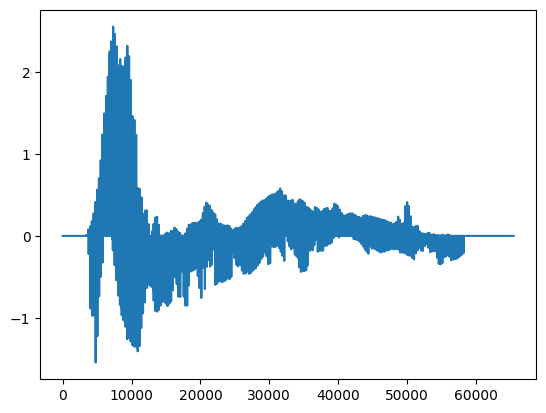

In [ ]:
plt.plot(attenu_obs.reshape((256, 256)).flatten() - z_image.detach().numpy().reshape((256, 256)).flatten())

In [324]:
z_image_np.shape

(1, 65536)

In [327]:
np.diag(np.full(z_image_np.flatten().shape[0], 0.1))

array([[0.1, 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0.1, 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0.1, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0.1, 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0.1, 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0.1]], shape=(65536, 65536))

In [28]:



# gaussian_obs_image = torch.distributions.Normal(torch.tensor(attenu_obs), torch.full(attenu_obs.shape, 0.1))

x = model_nf.sample(1)[0].detach()
z = model_nf.inverse(x)
z_image = torch.matmul(z, torch.tensor(attenu_pca.components_).float()) + torch.tensor(attenu_pca.mean_)

z_image_np = z_image.detach().numpy()

#gaussian_z_image = np.random.multivariate_normal(z_image_np.flatten(), cov = np.diag(np.full(z_image_np.flatten().shape[0], 0.1)))

#gaussian_z_image = torch.distributions.Normal(torch.tensor(z_image), torch.full(z_image.shape, 0.1))
attenu_obs = attenu_pca.inverse_transform(attenu_latent_test_dataset[0][0].detach().numpy().reshape(1, -1))

#gaussian_z_image.log_prob(torch.tensor(attenu_obs))

# gaussian_obs_image.log_prob(z_image)[0][0]

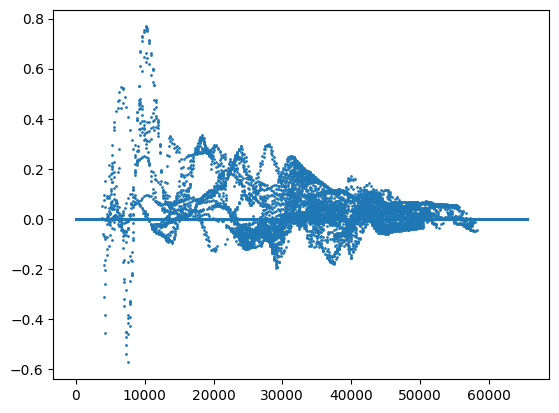

In [321]:
plt.scatter(np.arange((attenu_obs - z_image.detach().numpy()).flatten().shape[0]), (attenu_obs - z_image.detach().numpy()).flatten(), s = 1)

In [263]:
# use one sample from test dataset to serve as observation
attenu_obs = attenu_pca.inverse_transform(attenu_latent_test_dataset[0][0].detach().numpy().reshape(1, -1))

class custom_potential:
    def __init__(self, model_nf, model_pca, attenu_obs):
        self.model_nf = model_nf
        self.model_pca = model_pca
        self.attenu_obs = torch.tensor(attenu_obs)

        #self.gaussian_obs_image = torch.distributions.Normal(torch.tensor(attenu_obs), torch.full(attenu_obs.shape, 0.1))
    
    def log_posterior(self, params):
        x = params['x']

        log_p_prior = model_nf.log_prob(x)

        z = model_nf.inverse(x)
        z_image = torch.matmul(z, torch.tensor(self.model_pca.components_).float()) + torch.tensor(self.model_pca.mean_)
        #gaussian_z_image = torch.distributions.Normal(z_image, torch.full(attenu_obs.shape, 0.1))

        #print(gaussian_z_image.log_prob(self.attenu_obs)[0][0])

        mean_se = - torch.mean((torch.tensor(attenu_obs) - z_image) ** 2)

        mean_se = mean_se * 5000
        #print(mean_se)
        #print(log_p_prior)

        #print(mean_se)
        #print(log_p_prior)
        #print(torch.max(z_image))
        # print(model_nf.log_prob(x))
        #print(MSE)
        #print(model_nf.log_prob(x))
    
        return -(log_p_prior + mean_se)

#custom_potential = custom_potential(model_nf, attenu_pca)

# grad = torch.autograd.grad(custom_potential.forward(x), x, retain_graph= True)

import pyro
from pyro.infer.mcmc import MCMC, HMC, NUTS

# def potential_fn(params):
#     x = params['x']
#     return -model_nf.log_prob(x)

custom_potential = custom_potential(model_nf, attenu_pca, attenu_obs)

mcmc_kernel = NUTS(potential_fn = custom_potential.log_posterior)
mcmc = MCMC(mcmc_kernel, num_samples=200, warmup_steps=10, initial_params={"x": model_nf.sample(1)[0].detach()})
mcmc.run()
#nuts_kernel = NUTS(potential_fn = custom_potential.log_posterior)

# num_steps = 10
# samples = []
# num_samples = 50
# for k in range(num_samples):
#     x0 = model_nf.sample(1)[0]

#     for i in range(num_steps):
#         if i == 0:
#             initial_params = {"x": model_nf.sample(1)[0].detach(), "x0": x0.detach()}
#         else:
#             # print('x')
#             # print(model_nf.sample(1)[0].detach())
#             # print('x from last step')
#             # print(mcmc._samples['x'][0][0])
#             initial_params = {"x": model_nf.sample(1)[0].detach(), "x0": mcmc._samples['x'][0][0]}
        

#         if i == num_steps - 1:
#             mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params=initial_params)
#         else:
#             mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params=initial_params, disable_progbar=True)
        
#         mcmc.run()
#     samples.append(mcmc.get_samples()['x'][0][0])
    # print('x of new step')
    # print(mcmc._samples['x'])
# num_steps = 10
# for i in range(num_steps):
#     mcmc.run()
#     mcmc = MCMC(hmc_kernel, num_samples=1, warmup_steps=0, initial_params={"x": x.detach(), })

# samples = torch.stack(samples)

Warmup:   0%|          | 0/210 [00:00, ?it/s]

Sample: 100%|██████████| 210/210 [01:06,  3.15it/s, step size=6.15e-02, acc. prob=0.670]


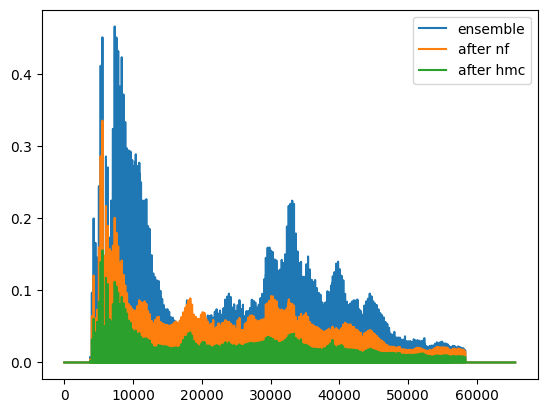

In [269]:
attenu_samples_hmc_latent = mcmc.get_samples()['x']
attenu_samples_hmc_latent = attenu_samples_hmc_latent[:, 0, :]
attenu_samples_hmc = attenu_pca.inverse_transform(attenu_samples_hmc_latent)
var_attenu_samples_hmc = np.var(attenu_samples_hmc, axis = 0)

plt.plot(var_attenu_ensemble_samples.flatten(), label = 'ensemble')
plt.plot(var_attenu_samples.flatten(), label = 'after nf')
plt.plot(var_attenu_samples_hmc.flatten(), label = 'after hmc')
plt.legend()

In [247]:
attenu_reconstruct = attenu_pca.inverse_transform(attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2))))
attenu_reconstruct_var = np.var(attenu_reconstruct, axis = 0).reshape((256, 256))

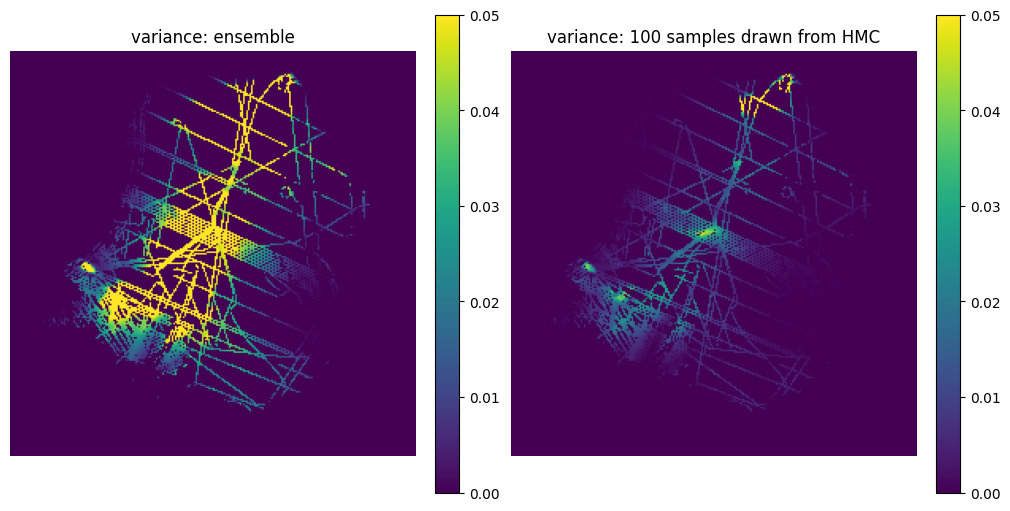

In [254]:
attenu_hmc_samples = attenu_pca.inverse_transform(mcmc.get_samples()['x'][:, 0, :]).reshape((mcmc.get_samples()['x'][:, 0, :].shape[0], 256, 256))
var_attenu_hmc_samples = np.nanvar(attenu_hmc_samples, axis = 0)

figs, axs = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

vmin = 0
vmax = 0.05

im0 = axs[0].imshow(var_attenu_ensemble_samples, vmin = vmin, vmax = vmax)
axs[0].set_title(f"variance: ensemble")
axs[0].set_axis_off()
plt.colorbar(im0)

im1 = axs[1].imshow(var_attenu_hmc_samples, vmin = vmin, vmax = vmax)
axs[1].set_title(f"variance: {attenu_hmc_samples.shape[0]} samples drawn from HMC")
axs[1].set_axis_off()
plt.colorbar(im1)

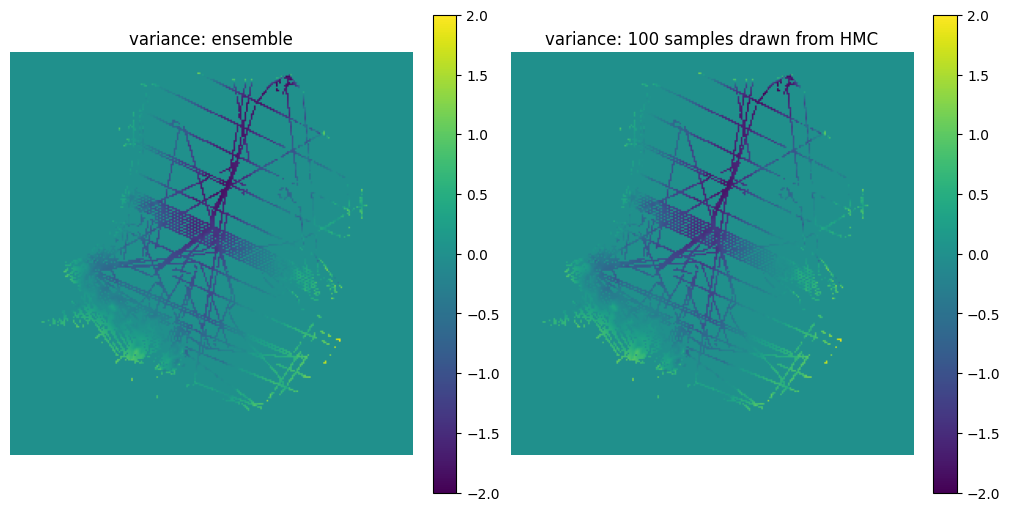

In [49]:
figs, axs = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

vmin = -2
vmax = 2

im0 = axs[0].imshow(np.nanmean(attenu_ensemble_samples, axis = 0), vmin = vmin, vmax = vmax)
axs[0].set_title(f"variance: ensemble")
axs[0].set_axis_off()
plt.colorbar(im0)

im1 = axs[1].imshow(np.nanmean(attenu_hmc_samples, axis = 0), vmin = vmin, vmax = vmax)
axs[1].set_title(f"variance: {attenu_hmc_samples.shape[0]} samples drawn from HMC")
axs[1].set_axis_off()
plt.colorbar(im1)

# Validation

#### validate by keeping only the first 20 componenents in PCA

In [ ]:
# load data: attenuation rate in PCA latent space
#num_epochs = 50
batch_size = 2

n_components_keep = 8

#attenu_pca = sklearn.decomposition.PCA(n_components = 32)
attenu_pca = joblib.load('../testing/attenu_pca2026-06-24 15:25:36.840671.pkl')
attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']

attenu_pca_components_cutoff = attenu_pca.components_[0:n_components_keep, :]
attenu_latent_cutoff = (attenu_pca_components_cutoff @ (attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)) - attenu_pca.mean_).T).T
attenu_latent_cutoff = torch.tensor(attenu_latent_cutoff).float()

# import joblib
# #joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 
# torch.save(attenu_latent_cutoff, 'attenu_latent_cutoff_pca.pt')

# train val test split
attenu_latent_cutoff_dataset = TensorDataset(attenu_latent_cutoff, attenu_latent_cutoff)

train_size = (int(0.7 * len(attenu_latent_cutoff)) // batch_size) * batch_size
val_size = int((len(attenu_latent_cutoff) - train_size)/2)
test_size = int(len(attenu_latent_cutoff) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_cutoff_train_dataset, attenu_latent_cutoff_val_dataset, attenu_latent_cutoff_test_dataset = random_split(attenu_latent_cutoff_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_cutoff_train_dataloader = DataLoader(attenu_latent_cutoff_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_val_dataloader = DataLoader(attenu_latent_cutoff_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_test_dataloader = DataLoader(attenu_latent_cutoff_test_dataset, batch_size = batch_size, shuffle = 1)

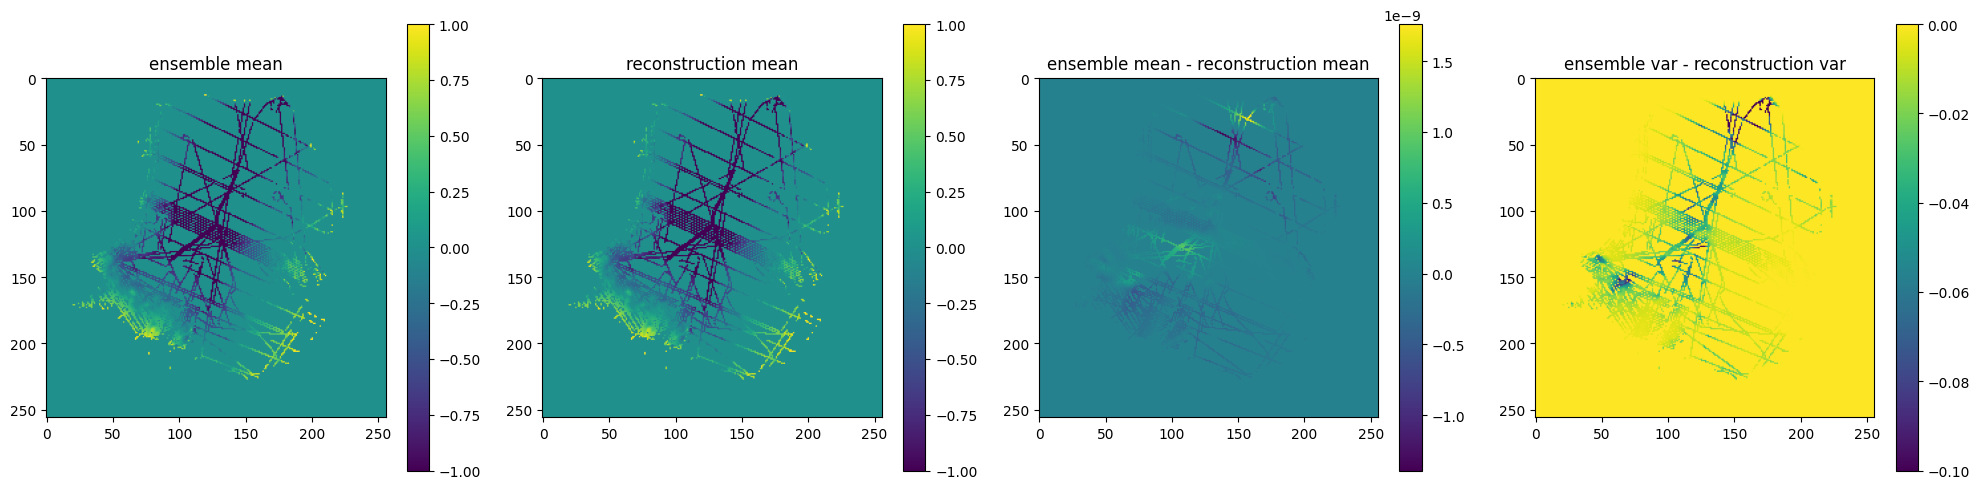

In [201]:
attenu_pca_cutoff_reconstruct = ((attenu_pca_components_cutoff.T @ attenu_latent_cutoff.T.detach().numpy()).T + attenu_pca.mean_.T)
attenu_pca_cutoff_reconstruct = attenu_pca_cutoff_reconstruct.reshape((-1, int(np.sqrt(attenu_pca_cutoff_reconstruct.shape[1])), int(np.sqrt(attenu_pca_cutoff_reconstruct.shape[1]))))

attenu_pca_cutoff_reconstruct_mean = np.mean(attenu_pca_cutoff_reconstruct, axis = 0)
attenu_fromEm_standard_mean = np.mean(attenu_fromEm_standard, axis = 0)
attenu_fromEm_standard_mean = attenu_fromEm_standard_mean[0, :, :]

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

vmin = -1
vmax = 1

im0 = ax[0].imshow(attenu_fromEm_standard_mean, vmin = vmin, vmax = vmax)
ax[0].set_title("ensemble mean")
plt.colorbar(im0)

im1 = ax[1].imshow(attenu_pca_cutoff_reconstruct_mean, vmin = vmin, vmax = vmax)
ax[1].set_title("reconstruction mean")
plt.colorbar(im1)

im2 = ax[2].imshow(attenu_pca_cutoff_reconstruct_mean - attenu_fromEm_standard_mean)
ax[2].set_title("ensemble mean - reconstruction mean")
plt.colorbar(im2)

im3 = ax[3].imshow((np.var(attenu_pca_cutoff_reconstruct, axis = 0) - np.var(attenu_fromEm_standard, axis = 0))[0, :, :], vmin = -0.1, vmax = 0)
ax[3].set_title("ensemble var - reconstruction var")
plt.colorbar(im3)

plt.tight_layout()

In [233]:
# Set up model_nf
in_features = int(attenu_latent_cutoff.shape[1]/2)

# Define list of flows
num_layers = 8
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([in_features, 64, 64, in_features * 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(in_features * 2, mode='swap'))

# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(in_features * 2)

# Construct flow model_nf
model_nf = nf.NormalizingFlow(base, flows)

model_nf

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=4, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): LeakyReLU(negative_slope=0.0)
              (4): Linear(in_features=64, out_features=8, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=4, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): Le

In [234]:
# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf
max_epoch = 500
early_stopping_threshold = 1e-6

epoch_loss = np.array([])
epoch_loss_val = np.array([])

optimizer = torch.optim.Adam(model_nf.parameters(), lr=1e-5, weight_decay=1e-5)
model_nf.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_cutoff_train_dataloader:
            # Compute loss
            loss = model_nf.forward_kld(train_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_cutoff_val_dataloader:
            # Compute loss
            val_loss = model_nf.forward_kld(val_batch)

            # Do backprop and optimizer step
            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                optimizer.step()
                running_loss_val += val_loss.item() * val_batch.size(0)
        
        #print(running_loss)

        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_
            print(f"Epoch loss slope: {epoch_loss_slope}")

            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")

            if (np.abs(epoch_loss_slope) < early_stopping_threshold) or (np.abs(epoch_loss_val_slope) < early_stopping_threshold):
                print("Early stopping")
                break

        end.record()

        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

    torch.save(model_nf.state_dict(), f'realNVP_cutoff_{datetime.datetime.now()}.pth')
    np.savez(f'realNVP_cutoff_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf.state_dict(), f'realNVP_cutoff_{datetime.datetime.now()}.pth')
    np.savez(f'realNVP_cutoff_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/500], loss: 99.5563, validation loss: 468.8780, time elapsed = 0.20 s
Epoch [2/500], loss: 78.7722, validation loss: 370.9916, time elapsed = 0.12 s
Epoch [3/500], loss: 68.5035, validation loss: 322.6293, time elapsed = 0.12 s
Epoch [4/500], loss: 59.6536, validation loss: 280.9490, time elapsed = 0.12 s
Epoch [5/500], loss: 53.8790, validation loss: 253.7527, time elapsed = 0.12 s
Epoch [6/500], loss: 49.2971, validation loss: 232.1732, time elapsed = 0.12 s
Epoch [7/500], loss: 45.8242, validation loss: 215.8172, time elapsed = 0.12 s
Epoch [8/500], loss: 42.5708, validation loss: 200.4946, time elapsed = 0.12 s
Epoch [9/500], loss: 40.1090, validation loss: 188.9004, time elapsed = 0.12 s
Epoch [10/500], loss: 38.0983, validation loss: 179.4305, time elapsed = 0.17 s
Epoch [11/500], loss: 36.2850, validation loss: 170.8908, time elapsed = 0.12 s
Epoch [12/500], loss: 34.6674, validation loss: 163.2724, time elapsed = 0.12 s
Epoch [13/500], loss: 33.3565, validation loss: 1

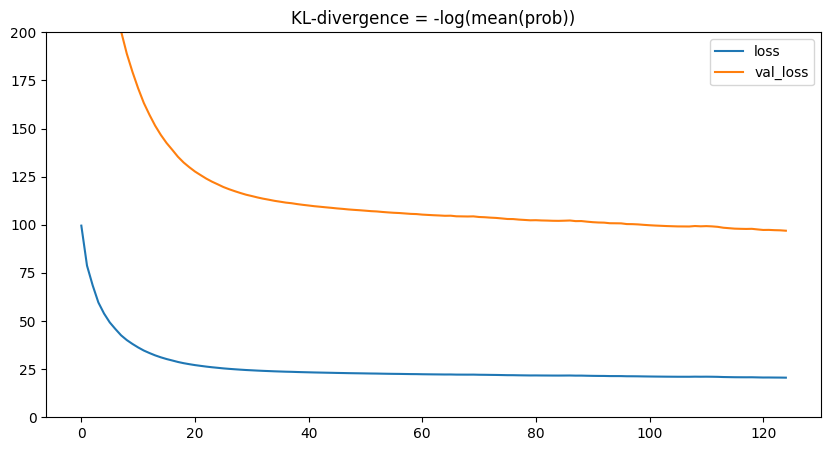

In [236]:
# Plot loss
#epoch_loss = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss']
#epoch_loss_val = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss_val']

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss[0:-1], label='loss')
plt.plot(epoch_loss_val[0:-1], label='val_loss')
plt.ylim((0, 200))
plt.title('KL-divergence = -log(mean(prob))')
plt.legend()
plt.show()


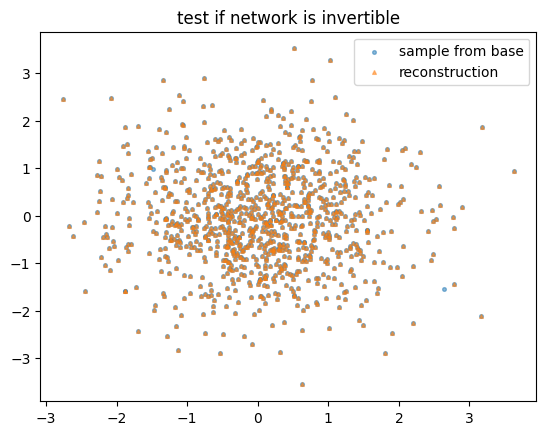

In [237]:
#model_nf.load_state_dict(torch.load('../testing/realNVP_2026-07-01 15:44:34.646170.pth', weights_only=True))
model_nf.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf.forward(x0)
x1 = model_nf.sample(1000)[0]
x0_from_x1_from_x0 = model_nf.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

plt.scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
plt.scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
plt.title("test if network is invertible")
plt.legend()